#  Comparação de Performance: PostgreSQL vs MongoDB
## Inserção de 1 Milhão de Registros

Este notebook realiza uma comparação de performance entre **PostgreSQL** e **MongoDB** ao inserir 1 milhão de registros, analisando:
- Tempo de inserção (individual e em lote)
- Uso de memória
- Throughput (registros/segundo)
- Visualizações comparativas

## 1. Instalação das Dependências

In [24]:
!pip install psycopg2-binary pymongo faker pandas matplotlib seaborn tqdm psutil ipywidgets --quiet

## 2. Importações

In [25]:
!pip install --upgrade jupyter ipywidgets --quiet

In [26]:
import time
import random
import psutil
import os
import threading
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from datetime import datetime
from faker import Faker
#from tqdm.notebook import tqdm
from tqdm import tqdm
import uuid

# Banco de dados
import psycopg2
from psycopg2.extras import execute_batch
from pymongo import MongoClient

# Configuração de estilo dos gráficos
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

fake = Faker('pt_BR')
Faker.seed(42)
random.seed(42)

print(" Dependências importadas com sucesso!")

 Dependências importadas com sucesso!


## 3. Configurações de Conexão

> **Configure as credenciais dos seus bancos de dados abaixo.**

In [27]:
# ─── PostgreSQL ───────────────────────────────────────────
PG_CONFIG = {
    'host':     'localhost',
    'port':     5432,
    'dbname':   'postgres',
    'user':     'postgres',
    'password': 'univassouras'
}

# ─── MongoDB ──────────────────────────────────────────────
MONGO_URI        = 'mongodb://localhost:27017/'
MONGO_DB         = 'benchmark_db'
MONGO_COLLECTION = 'usuarios'

# ─── Parâmetros do benchmark ──────────────────────────────
TOTAL_RECORDS = 1_000_000   # 1 milhão de registros
BATCH_SIZE    = 10_000      # tamanho do lote

print(f"Configurado para inserir {TOTAL_RECORDS:,} registros em lotes de {BATCH_SIZE:,}")

Configurado para inserir 1,000,000 registros em lotes de 10,000


## 4. Geração de Dados Sintéticos

In [28]:
def gerar_lote(n: int) -> list[dict]:
    """Gera n registros de usuários sintéticos."""
    return [
        {
            'nome':      fake.name(),
            'email':     f"{uuid.uuid4().hex}@{fake.free_email_domain()}",  # ← sem fake.unique
            'idade':     random.randint(18, 80),
            'cidade':    fake.city(),
            'estado':    fake.state_abbr(),
            'salario':   round(random.uniform(1412.0, 50000.0), 2),
            'ativo':     random.choice([True, False]),
            'criado_em': datetime.now(),
            'score':     round(random.uniform(0, 100), 4),
        }
        for _ in range(n)
    ]

# Preview dos dados
sample = gerar_lote(3)
pd.DataFrame(sample)

,nome,email,idade,cidade,estado,salario,ativo,criado_em,score
0,Brenda Alves,1e75d4a906d04b15b9d0efee0c6c190d@bol.com.br,58,Câmara,BA,6821.35,False,2026-03-13 21:48:40.340180,24.4892
1,Srta. Ísis Borges,b6acd090c8f546dc9f7b2ddafc89910c@outlook.com.br,26,Alves,AP,37195.66,True,2026-03-13 21:48:40.340180,59.0493
2,Igor Montenegro,e45ffb8cc0cd42c9bd2b99ffd6249be4@gmail.com,20,Silva,RS,2859.79,True,2026-03-13 21:48:40.340180,23.2661


## 5. Benchmark — PostgreSQL

In [29]:
def preparar_postgres(config: dict):
    """Cria (ou recria) a tabela de benchmark no PostgreSQL."""
    conn = psycopg2.connect(**config)
    conn.autocommit = True
    cur = conn.cursor()

    cur.execute("DROP TABLE IF EXISTS usuarios;")
    cur.execute("""
        CREATE TABLE usuarios (
            id        SERIAL PRIMARY KEY,
            nome      VARCHAR(120),
            email     VARCHAR(200) UNIQUE,
            idade     SMALLINT,
            cidade    VARCHAR(100),
            estado    CHAR(2),
            salario   NUMERIC(10,2),
            ativo     BOOLEAN,
            criado_em TIMESTAMP,
            score     FLOAT
        );
    """)
    cur.close()
    conn.close()
    print("Tabela PostgreSQL pronta.")


def benchmark_postgres(config: dict, total: int, batch: int) -> dict:
    """Insere `total` registros no PostgreSQL em lotes de `batch`."""
    conn = psycopg2.connect(**config)
    cur  = conn.cursor()

    sql = """
        INSERT INTO usuarios (nome, email, idade, cidade, estado, salario, ativo, criado_em, score)
        VALUES (%(nome)s, %(email)s, %(idade)s, %(cidade)s, %(estado)s,
                %(salario)s, %(ativo)s, %(criado_em)s, %(score)s)
    """

    tempos_lote   = []
    mem_snapshots = []
    processo      = psutil.Process(os.getpid())
    n_lotes       = total // batch

    inicio_total = time.perf_counter()

    for i in tqdm(range(n_lotes), desc="PostgreSQL", colour="blue"):
        dados = gerar_lote(batch)
        t0    = time.perf_counter()
        execute_batch(cur, sql, dados, page_size=batch)
        conn.commit()
        tempos_lote.append(time.perf_counter() - t0)
        mem_snapshots.append(processo.memory_info().rss / 1024 / 1024)  # MB

    tempo_total = time.perf_counter() - inicio_total
    cur.close()
    conn.close()

    return {
        'db':           'PostgreSQL',
        'total':        total,
        'batch':        batch,
        'tempo_total':  tempo_total,
        'throughput':   total / tempo_total,
        'tempos_lote':  tempos_lote,
        'mem_snapshots': mem_snapshots,
        'mem_media_mb': np.mean(mem_snapshots),
        'mem_max_mb':   np.max(mem_snapshots),
    }

In [30]:
preparar_postgres(PG_CONFIG)
resultado_pg = benchmark_postgres(PG_CONFIG, TOTAL_RECORDS, BATCH_SIZE)

print(f"\nPostgreSQL — Resultado")
print(f"   Tempo total : {resultado_pg['tempo_total']:.2f}s")
print(f"   Throughput  : {resultado_pg['throughput']:,.0f} registros/s")
print(f"   Memória máx : {resultado_pg['mem_max_mb']:.1f} MB")

Tabela PostgreSQL pronta.


PostgreSQL: 100%|██████████| 100/100 [00:54<00:00,  1.82it/s]


PostgreSQL — Resultado
   Tempo total : 54.92s
   Throughput  : 18,209 registros/s
   Memória máx : 145.6 MB


## 6. Benchmark — MongoDB

In [31]:
def preparar_mongo(uri: str, db_name: str, col_name: str):
    """Limpa a coleção de benchmark no MongoDB."""
    client = MongoClient(uri)
    client[db_name][col_name].drop()
    client.close()
    print("Coleção MongoDB pronta.")


def benchmark_mongo(uri: str, db_name: str, col_name: str,
                    total: int, batch: int) -> dict:
    """Insere `total` registros no MongoDB em lotes de `batch`."""
    client     = MongoClient(uri)
    colecao    = client[db_name][col_name]

    tempos_lote   = []
    mem_snapshots = []
    processo      = psutil.Process(os.getpid())
    n_lotes       = total // batch

    inicio_total = time.perf_counter()

    for i in tqdm(range(n_lotes), desc="MongoDB   ", colour="green"):
        dados = gerar_lote(batch)
        t0    = time.perf_counter()
        colecao.insert_many(dados, ordered=False)
        tempos_lote.append(time.perf_counter() - t0)
        mem_snapshots.append(processo.memory_info().rss / 1024 / 1024)

    tempo_total = time.perf_counter() - inicio_total
    client.close()

    return {
        'db':            'MongoDB',
        'total':         total,
        'batch':         batch,
        'tempo_total':   tempo_total,
        'throughput':    total / tempo_total,
        'tempos_lote':   tempos_lote,
        'mem_snapshots': mem_snapshots,
        'mem_media_mb':  np.mean(mem_snapshots),
        'mem_max_mb':    np.max(mem_snapshots),
    }

In [32]:
preparar_mongo(MONGO_URI, MONGO_DB, MONGO_COLLECTION)
resultado_mg = benchmark_mongo(MONGO_URI, MONGO_DB, MONGO_COLLECTION,
                                TOTAL_RECORDS, BATCH_SIZE)

print(f"\n MongoDB — Resultado")
print(f"   Tempo total : {resultado_mg['tempo_total']:.2f}s")
print(f"   Throughput  : {resultado_mg['throughput']:,.0f} registros/s")
print(f"   Memória máx : {resultado_mg['mem_max_mb']:.1f} MB")

Coleção MongoDB pronta.


MongoDB   : 100%|██████████| 100/100 [00:23<00:00,  4.24it/s]


 MongoDB — Resultado
   Tempo total : 23.61s
   Throughput  : 42,364 registros/s
   Memória máx : 140.6 MB


## 7. Análise Comparativa

In [ ]:
# Tabela resumo
resumo = pd.DataFrame([
    {
        'Banco de Dados':       r['db'],
        'Registros Inseridos':  f"{r['total']:,}",
        'Tempo Total (s)':      f"{r['tempo_total']:.2f}",
        'Throughput (reg/s)':   f"{r['throughput']:,.0f}",
        'Memória Média (MB)':   f"{r['mem_media_mb']:.1f}",
        'Memória Máxima (MB)':  f"{r['mem_max_mb']:.1f}",
        'Tempo médio/lote (s)': f"{np.mean(r['tempos_lote']):.3f}",
    }
    for r in [resultado_pg, resultado_mg]
])

resumo.set_index('Banco de Dados', inplace=True)
resumo.style.set_caption('Resumo Comparativo — 1 Milhão de Inserções')

,Registros Inseridos,Tempo Total (s),Throughput (reg/s),Memória Média (MB),Memória Máxima (MB),Tempo médio/lote (s)
Banco de Dados,,,,,,
PostgreSQL,"1,000,000",54.92,"18,209",144.6,145.6,0.381
MongoDB,"1,000,000",23.61,"42,364",140.4,140.6,0.062


## 8. Visualizações

C:\Users\UNIVASSOURAS\AppData\Local\Temp\ipykernel_18256\2318321189.py:74: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\UNIVASSOURAS\AppData\Local\Temp\ipykernel_18256\2318321189.py:75: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Arial.
  plt.savefig('benchmark_resultado.png', dpi=150, bbox_inches='tight')
c:\Users\UNIVASSOURAS\Documents\BD_NoSQL\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


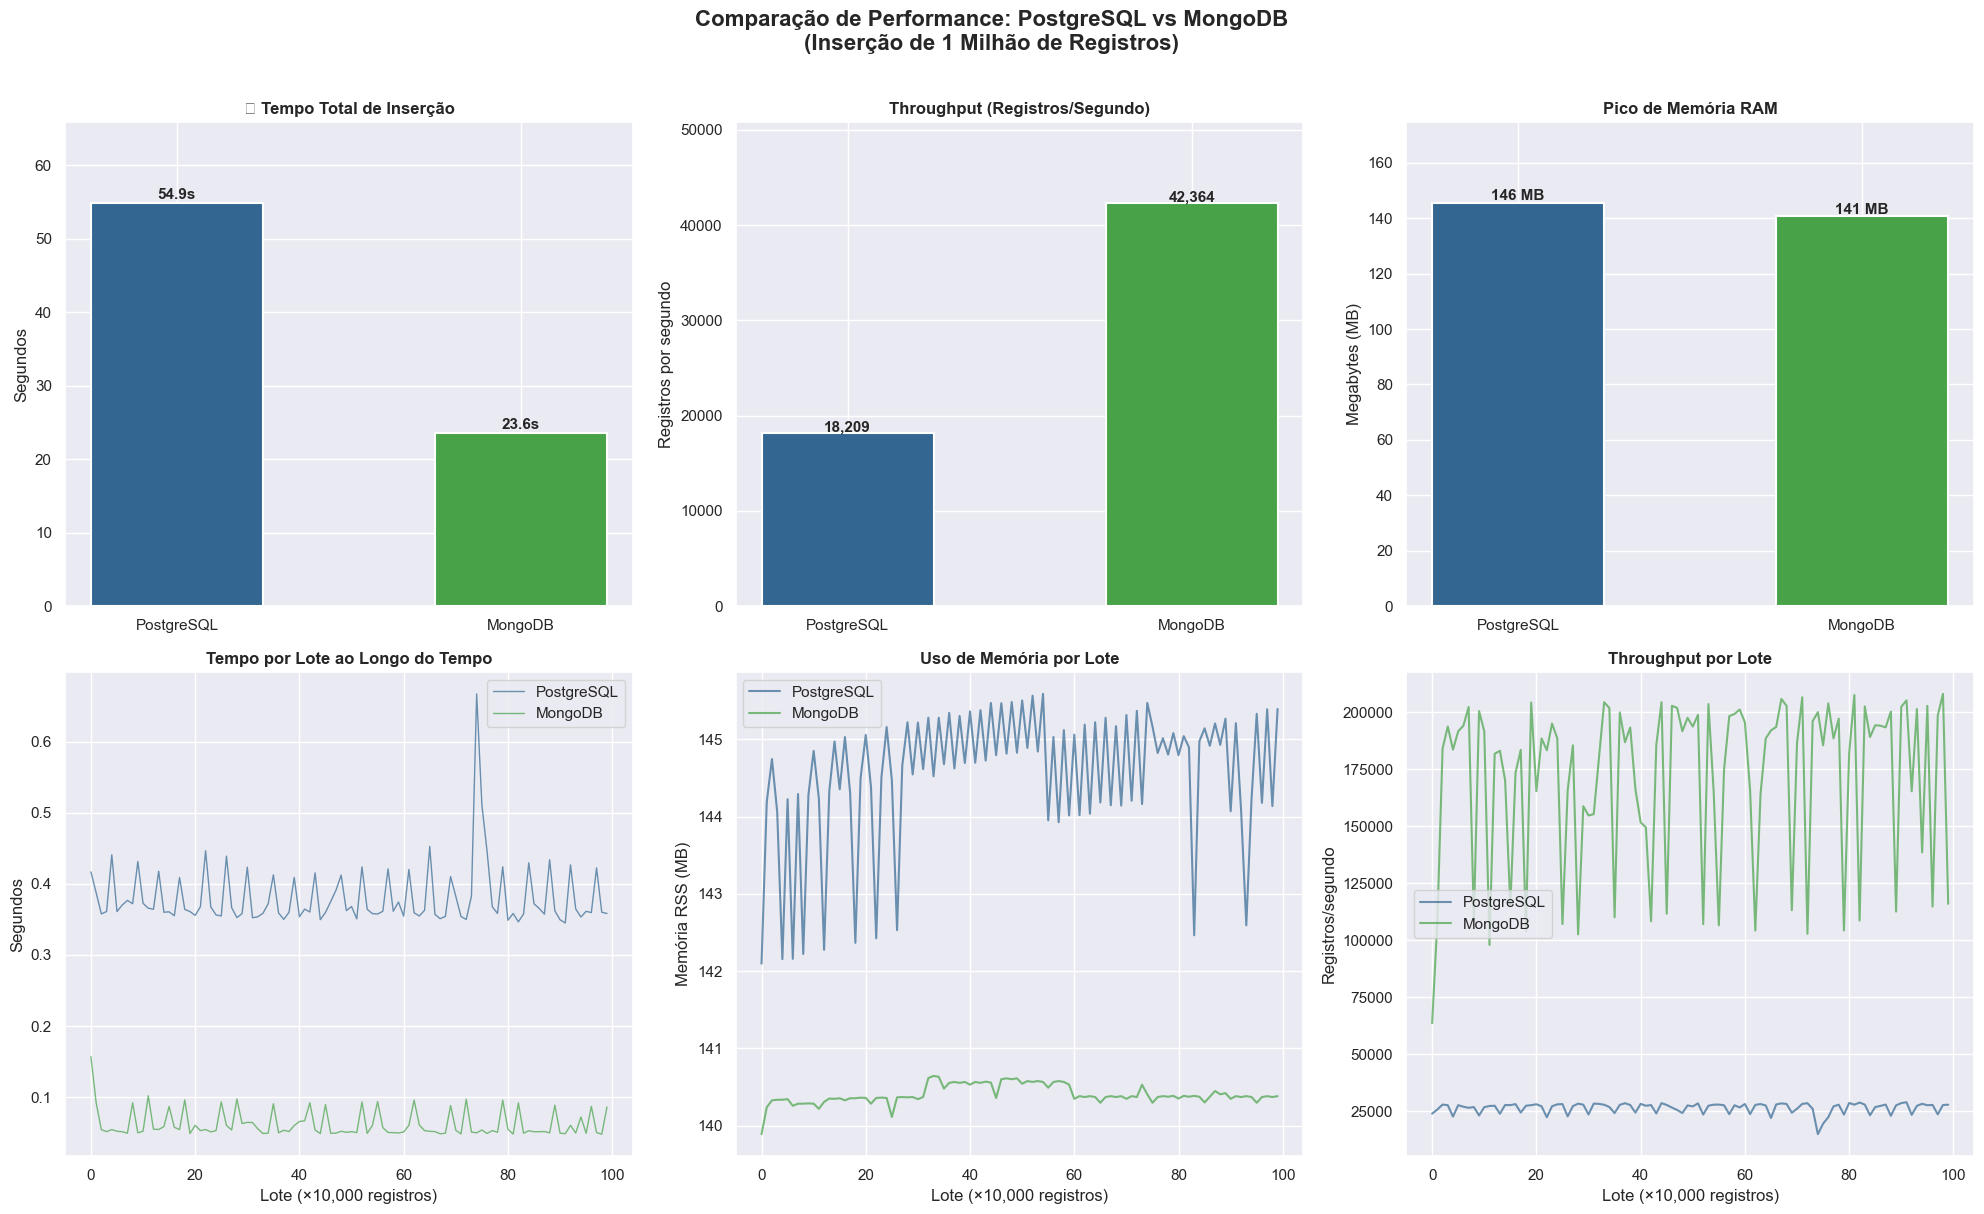

Gráficos gerados com sucesso!


In [34]:
# ─── Paleta de cores ──────────────────────────────────────
COR_PG    = '#336791'   # azul PostgreSQL
COR_MONGO = '#47A248'   # verde MongoDB

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Comparação de Performance: PostgreSQL vs MongoDB\n(Inserção de 1 Milhão de Registros)',
             fontsize=16, fontweight='bold', y=1.01)

# ── 1. Tempo Total ────────────────────────────────────────
ax = axes[0, 0]
dbs    = ['PostgreSQL', 'MongoDB']
tempos = [resultado_pg['tempo_total'], resultado_mg['tempo_total']]
bars   = ax.bar(dbs, tempos, color=[COR_PG, COR_MONGO], width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, tempos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}s', ha='center', fontweight='bold', fontsize=11)
ax.set_title('⏱ Tempo Total de Inserção', fontweight='bold')
ax.set_ylabel('Segundos')
ax.set_ylim(0, max(tempos) * 1.2)

# ── 2. Throughput ─────────────────────────────────────────
ax = axes[0, 1]
tps = [resultado_pg['throughput'], resultado_mg['throughput']]
bars = ax.bar(dbs, tps, color=[COR_PG, COR_MONGO], width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, tps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,.0f}', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Throughput (Registros/Segundo)', fontweight='bold')
ax.set_ylabel('Registros por segundo')
ax.set_ylim(0, max(tps) * 1.2)

# ── 3. Memória Máxima ─────────────────────────────────────
ax = axes[0, 2]
mems = [resultado_pg['mem_max_mb'], resultado_mg['mem_max_mb']]
bars = ax.bar(dbs, mems, color=[COR_PG, COR_MONGO], width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, mems):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f} MB', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Pico de Memória RAM', fontweight='bold')
ax.set_ylabel('Megabytes (MB)')
ax.set_ylim(0, max(mems) * 1.2)

# ── 4. Tempo por Lote (linha) ─────────────────────────────
ax = axes[1, 0]
x = np.arange(len(resultado_pg['tempos_lote']))
ax.plot(x, resultado_pg['tempos_lote'], color=COR_PG,    alpha=0.7, lw=1, label='PostgreSQL')
ax.plot(x, resultado_mg['tempos_lote'], color=COR_MONGO, alpha=0.7, lw=1, label='MongoDB')
ax.set_title('Tempo por Lote ao Longo do Tempo', fontweight='bold')
ax.set_xlabel(f'Lote (×{BATCH_SIZE:,} registros)')
ax.set_ylabel('Segundos')
ax.legend()

# ── 5. Uso de Memória Acumulado ───────────────────────────
ax = axes[1, 1]
ax.plot(x, resultado_pg['mem_snapshots'], color=COR_PG,    alpha=0.7, lw=1.5, label='PostgreSQL')
ax.plot(x, resultado_mg['mem_snapshots'], color=COR_MONGO, alpha=0.7, lw=1.5, label='MongoDB')
ax.set_title('Uso de Memória por Lote', fontweight='bold')
ax.set_xlabel(f'Lote (×{BATCH_SIZE:,} registros)')
ax.set_ylabel('Memória RSS (MB)')
ax.legend()

# ── 6. Throughput Acumulado ───────────────────────────────
ax = axes[1, 2]
registros_por_lote = BATCH_SIZE
thr_pg    = [registros_por_lote / t for t in resultado_pg['tempos_lote']]
thr_mg    = [registros_por_lote / t for t in resultado_mg['tempos_lote']]
ax.plot(x, thr_pg, color=COR_PG,    alpha=0.7, lw=1.5, label='PostgreSQL')
ax.plot(x, thr_mg, color=COR_MONGO, alpha=0.7, lw=1.5, label='MongoDB')
ax.set_title('Throughput por Lote', fontweight='bold')
ax.set_xlabel(f'Lote (×{BATCH_SIZE:,} registros)')
ax.set_ylabel('Registros/segundo')
ax.legend()

plt.tight_layout()
plt.savefig('benchmark_resultado.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficos gerados com sucesso!")

## 9. Distribuição dos Tempos por Lote (Boxplot)

C:\Users\UNIVASSOURAS\AppData\Local\Temp\ipykernel_18256\389016177.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados_box, labels=['PostgreSQL', 'MongoDB'],


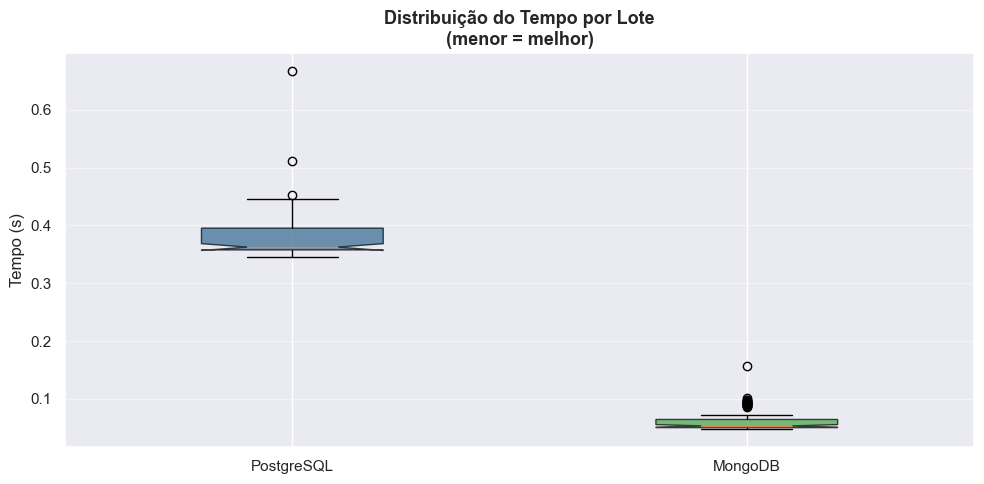

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))

dados_box = [
    resultado_pg['tempos_lote'],
    resultado_mg['tempos_lote']
]

bp = ax.boxplot(dados_box, labels=['PostgreSQL', 'MongoDB'],
                patch_artist=True, notch=True, widths=0.4)

for patch, cor in zip(bp['boxes'], [COR_PG, COR_MONGO]):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

ax.set_title('Distribuição do Tempo por Lote\n(menor = melhor)', fontweight='bold', fontsize=13)
ax.set_ylabel('Tempo (s)')
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

## 10. Conclusão Automática

In [36]:
vencedor_tempo = 'MongoDB' if resultado_mg['tempo_total'] < resultado_pg['tempo_total'] else 'PostgreSQL'
vencedor_mem   = 'MongoDB' if resultado_mg['mem_max_mb']  < resultado_pg['mem_max_mb']  else 'PostgreSQL'
vencedor_thr   = 'MongoDB' if resultado_mg['throughput']  > resultado_pg['throughput']  else 'PostgreSQL'

dif_tempo_pct = abs(resultado_pg['tempo_total'] - resultado_mg['tempo_total']) / \
                max(resultado_pg['tempo_total'], resultado_mg['tempo_total']) * 100

dif_thr_pct   = abs(resultado_pg['throughput'] - resultado_mg['throughput']) / \
                max(resultado_pg['throughput'], resultado_mg['throughput']) * 100

print("=" * 60)
print("RESULTADO FINAL — 1 MILHÃO DE INSERÇÕES")
print("=" * 60)
print(f"\n{'Métrica':<30} {'PostgreSQL':>12} {'MongoDB':>12}")
print("-" * 56)
print(f"{'Tempo Total (s)':<30} {resultado_pg['tempo_total']:>12.2f} {resultado_mg['tempo_total']:>12.2f}")
print(f"{'Throughput (reg/s)':<30} {resultado_pg['throughput']:>12,.0f} {resultado_mg['throughput']:>12,.0f}")
print(f"{'Memória Média (MB)':<30} {resultado_pg['mem_media_mb']:>12.1f} {resultado_mg['mem_media_mb']:>12.1f}")
print(f"{'Memória Máxima (MB)':<30} {resultado_pg['mem_max_mb']:>12.1f} {resultado_mg['mem_max_mb']:>12.1f}")
print(f"{'Tempo Médio/Lote (s)':<30} {np.mean(resultado_pg['tempos_lote']):>12.3f} {np.mean(resultado_mg['tempos_lote']):>12.3f}")
print("-" * 56)
print(f"\n Mais rápido    → {vencedor_tempo} ({dif_tempo_pct:.1f}% de diferença)")
print(f"Maior throughput → {vencedor_thr} ({dif_thr_pct:.1f}% de diferença)")
print(f"Menor memória  → {vencedor_mem}")
print("\n Observações:")
print("   • MongoDB tende a ser mais rápido em inserções puras pois não")
print("     precisa validar schema nem gerenciar índices por padrão.")
print("   • PostgreSQL oferece ACID completo, o que adiciona overhead.")
print("   • Para workloads de escrita intensiva sem necessidade de")
print("     transações complexas, MongoDB é frequentemente superior.")
print("   • Para consistência, integridade relacional e queries ad-hoc,")
print("     PostgreSQL é a escolha mais robusta.")
print("=" * 60)

RESULTADO FINAL — 1 MILHÃO DE INSERÇÕES

Métrica                          PostgreSQL      MongoDB
--------------------------------------------------------
Tempo Total (s)                       54.92        23.61
Throughput (reg/s)                   18,209       42,364
Memória Média (MB)                    144.6        140.4
Memória Máxima (MB)                   145.6        140.6
Tempo Médio/Lote (s)                  0.381        0.062
--------------------------------------------------------

 Mais rápido    → MongoDB (57.0% de diferença)
Maior throughput → MongoDB (57.0% de diferença)
Menor memória  → MongoDB

 Observações:
   • MongoDB tende a ser mais rápido em inserções puras pois não
     precisa validar schema nem gerenciar índices por padrão.
   • PostgreSQL oferece ACID completo, o que adiciona overhead.
   • Para workloads de escrita intensiva sem necessidade de
     transações complexas, MongoDB é frequentemente superior.
   • Para consistência, integridade relacional e queri